# Phase 3: EEG Signal Preprocessing Pipeline

Apply signal processing techniques to clean and prepare EEG data for feature extraction.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import butter, filtfilt
import pickle
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Imports successful!")

Imports successful!


## Step 1: Load Raw Data

In [17]:
# Load raw EEG dataset
data_path = '../data/raw/eeg_dataset.pkl'

with open(data_path, 'rb') as f:
    data_dict = pickle.load(f)

eeg_data = data_dict['eeg_data']  # Shape: (n_samples, n_channels, n_timepoints)
labels = data_dict['labels']
subject_ids = data_dict['subject_ids']
channel_names = data_dict['channel_names']
fs = data_dict['fs']
metadata = data_dict['metadata']

print(f"Dataset loaded!")
print(f"  EEG shape: {eeg_data.shape}")
print(f"  Channels: {eeg_data.shape[1]}")
print(f"  Sampling rate: {fs} Hz")
print(f"  Class distribution: {np.unique(labels, return_counts=True)}")

Dataset loaded!
  EEG shape: (30, 62, 50000)
  Channels: 62
  Sampling rate: 200 Hz
  Class distribution: (array([0, 1]), array([15, 15]))


## Step 2: Design Bandpass Filter

In [18]:
def design_bandpass_filter(fs, lowcut=1, highcut=50, order=5):
    """
    Design a Butterworth bandpass filter.
    
    Parameters:
    -----------
    fs : float
        Sampling frequency (Hz)
    lowcut : float
        Lower cutoff frequency (Hz)
    highcut : float
        Upper cutoff frequency (Hz)
    order : int
        Filter order
    
    Returns:
    --------
    b, a : filter coefficients
    """
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Design filter
b, a = design_bandpass_filter(fs, lowcut=1, highcut=50, order=5)
print(f"Bandpass filter designed (1-50 Hz, order=5)")

Bandpass filter designed (1-50 Hz, order=5)


## Step 3: Apply Preprocessing to All Signals

In [13]:
def preprocess_eeg_signal(signal_data, fs, lowcut=1, highcut=50):
    """
    Apply complete preprocessing pipeline to EEG signal.
    
    Steps:
    1. Bandpass filter (1-50 Hz)
    2. Z-score normalization
    
    Parameters:
    -----------
    signal_data : array, shape (n_channels, n_timepoints)
        Raw EEG signal
    fs : float
        Sampling frequency
    
    Returns:
    --------
    preprocessed : array, same shape
        Cleaned and normalized signal
    """
    b, a = design_bandpass_filter(fs, lowcut, highcut)
    n_channels = signal_data.shape[0]
    preprocessed = np.zeros_like(signal_data)
    
    for ch in range(n_channels):
        # Bandpass filter using zero-phase filtering (filtfilt)
        filtered = filtfilt(b, a, signal_data[ch, :])
        
        # Z-score normalization
        normalized = (filtered - filtered.mean()) / (filtered.std() + 1e-8)
        preprocessed[ch, :] = normalized
    
    return preprocessed

print("Preprocessing function defined")

Preprocessing function defined


In [19]:
# Apply preprocessing to all subjects
print(f"\nApplying preprocessing to {len(eeg_data)} EEG recordings...\n")

preprocessed_data = []
for i, raw_signal in enumerate(eeg_data):
    preprocessed = preprocess_eeg_signal(raw_signal, fs, lowcut=1, highcut=50)
    preprocessed_data.append(preprocessed)
    
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(eeg_data)} recordings")

preprocessed_data = np.array(preprocessed_data)

print(f"\nPreprocessing complete!")
print(f"  Preprocessed shape: {preprocessed_data.shape}")
print(f"  Mean across all data: {preprocessed_data.mean():.6f}")
print(f"  Std across all data: {preprocessed_data.std():.6f}")


Applying preprocessing to 30 EEG recordings...

  Processed 10/30 recordings
  Processed 20/30 recordings
  Processed 30/30 recordings

Preprocessing complete!
  Preprocessed shape: (30, 62, 50000)
  Mean across all data: -0.000000
  Std across all data: 1.000000


## Step 4: Visualize Before/After Preprocessing

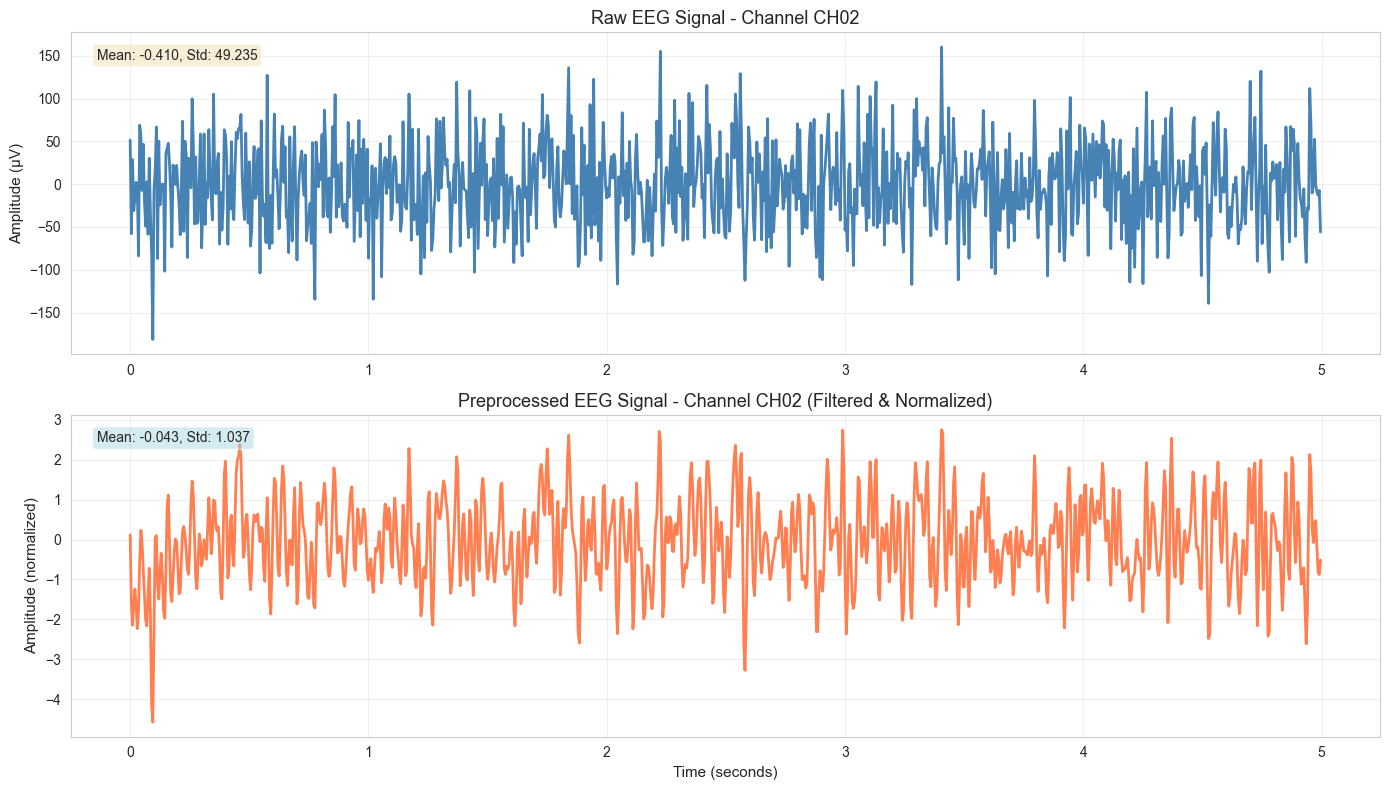

Visualization saved!


In [20]:
# Compare raw vs preprocessed for one subject
sample_idx = 0
channel_idx = 2  # F3 channel
time_window = 5  # seconds
n_samples = int(time_window * fs)

raw_signal = eeg_data[sample_idx, channel_idx, :n_samples]
preprocessed_signal = preprocessed_data[sample_idx, channel_idx, :n_samples]
time = np.arange(n_samples) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw signal
axes[0].plot(time, raw_signal, color='steelblue', linewidth=2)
axes[0].set_title(f'Raw EEG Signal - Channel {channel_names[channel_idx]}', fontsize=13)
axes[0].set_ylabel('Amplitude (µV)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.95, f'Mean: {raw_signal.mean():.3f}, Std: {raw_signal.std():.3f}',
             transform=axes[0].transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize=10, verticalalignment='top')

# Preprocessed signal
axes[1].plot(time, preprocessed_signal, color='coral', linewidth=2)
axes[1].set_title(f'Preprocessed EEG Signal - Channel {channel_names[channel_idx]} (Filtered & Normalized)', fontsize=13)
axes[1].set_ylabel('Amplitude (normalized)', fontsize=11)
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.95, f'Mean: {preprocessed_signal.mean():.3f}, Std: {preprocessed_signal.std():.3f}',
             transform=axes[1].transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
             fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.savefig('../results/plots/03_preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved!")

## Step 5: Save Preprocessed Data

In [21]:
# Save preprocessed data
preprocessed_dict = {
    'preprocessed_data': preprocessed_data,
    'labels': labels,
    'subject_ids': subject_ids,
    'channel_names': channel_names,
    'fs': fs,
    'metadata': metadata
}

save_path = '../data/preprocessed/preprocessed_dataset.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(preprocessed_dict, f)

print(f"Preprocessed dataset saved to {save_path}")
print(f"\n✅ Phase 3 Complete!")
print(f"\nNext: Phase 4 - Feature Extraction")

Preprocessed dataset saved to ../data/preprocessed/preprocessed_dataset.pkl

✅ Phase 3 Complete!

Next: Phase 4 - Feature Extraction
